In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
import sys
sys.path.append("../code/libs")
sys.path.append('helpers')

In [3]:
%reload_ext autoreload
%autoreload 2

import annotations as ans
import geo
import ios
import viz

In [4]:
gdf_users, gdf_tweets = geo.load_geo_data()
# Tweets: valid((102924, 58))
# Tweets: geo((59917, 58))
# Users: valid((83423, 22))
# Users: geo((46740, 22))
# ---
# Loading...
# Tweets: valid((102112, 58))
# Tweets: geo((59511, 58))
# Users: valid((82697, 22))
# Users: geo((46366, 22))

Loading...
Tweets: valid((102112, 58))
Tweets: geo((59511, 58))
Users: valid((82697, 22))
Users: geo((46366, 22))


In [5]:
gdf_tweets.head(2)

,tweet_id,corpus,score_q1,score_q2,score_q3,score_q4,score_q5,score_q6,score_q7,score_q8,...,status,centroid,ccode,geo_info,geometry,country,postcode,state,neighborhood,year
0,1417673516414013440,@loftmusik_ never been pregnant but if i were ...,0.732504,0.67069,0.760165,0.581427,0.681276,0.444975,0.526308,0.444595,...,None,POINT (-92.13127 34.75194),US,place,POINT (-92.13127 34.75194),NaN,NaN,NaN,NaN,2021
1,1416918506055081985,"@sbram94 since birth, too? i was a single-foot...",0.559071,0.550456,0.511389,0.504051,0.512161,0.312145,0.30415,0.24937,...,None,POINT (-68.98470 45.18841),US,place,POINT (-68.98470 45.18841),NaN,NaN,NaN,NaN,2021


In [18]:
for i, df in gdf_tweets.sample(10).iterrows():
    print(i, df.corpus)

60720 so i carry my baby for 9months and he weed on me 😫 thanks cade 💙
44889 my baby back on his weed smokin shit 🤩🤟🏼
74539 had a deep ass conversation last night about the baby, relationships, sex etc... weed make u talk a lot about unnecessary 💩
20623 i am in favor of weed being legal, but like, smoking anything during pregnancy is an enormous no no.
38457 if you smoke pot when you're pregnant, your baby will be a rastafarian.
52076 colorado is on the eve of allowing public consumption of marijuana smoking !!!! since the 1964 surgeon general's report, 2.5 million adults who were nonsmokers died from breathed secondhand smoke.(stat 2013) smoking during pregnancy results in over 1,000 infant deaths per year
85743 @mbw1013 @kellydlz does he smoke weed in the house??? i worry abt damage to baby...thats so not good..
39553 i'm pretty sure my mom smoke weed while pregnant with me and look how i turned out (:
53393 @coffeeteachwine @catofresearch lol i had to reread your tweet & then unders

In [25]:
gdf_tweets.country.unique()

array([nan, 'United States', 'Puerto Rico', 'Mexico', 'Canada', 'Norway',
       'Jersey', 'India', 'United Kingdom', 'Nepal', 'Nigeria', 'Brazil',
       'South Africa', 'Kenya', 'Ghana', 'Sweden', 'Dominican Republic',
       'Bahrain', 'Australia', 'Tanzania', 'Colombia', 'Spain',
       "Côte d'Ivoire", 'France', 'Liberia', 'China', 'Argentina',
       'Ireland', 'Venezuela', 'Bahamas', 'Laos', 'Poland', 'Portugal',
       'Czech Republic', 'Russian Federation', 'Italy', 'Oman', 'Myanmar',
       'Madagascar', 'Ukraine', 'Switzerland', 'Bosnia and Herzegovina',
       'Isle of Man', 'Romania', 'Greece', 'Estonia', 'New Zealand',
       'Turkiye', 'Albania', 'Belgium', 'Saint Lucia', 'Eswatini',
       'Guatemala', 'Philippines', 'Bermuda', 'Thailand', 'Japan',
       'Slovenia', 'Uganda', 'Saint Vincent and the Grenadines', 'Malta',
       'Germany', 'Lebanon', 'Finland', 'Chad', 'Vietnam', 'Somalia',
       'Saint Helena', 'Cameroon', 'Denmark', 'North Korea',
       'Papua New Gu

In [19]:
gdf_tweets.query("ccode=='DJ'")

,tweet_id,corpus,score_q1,score_q2,score_q3,score_q4,score_q5,score_q6,score_q7,score_q8,...,status,centroid,ccode,geo_info,geometry,country,postcode,state,neighborhood,year
100400,131048093125849088,my baby is fine the fact that i smoke weed. is...,0.536321,0.609536,0.505094,0.542362,0.580255,0.430644,0.280918,0.284861,...,None,POINT (42.84531 11.81460),DJ,user,POINT (42.84531 11.81460),Djibouti,None,Tadjourah تجرة,NaN,2011


In [6]:
gdf_tweets.groupby('geo_info', dropna=False).tweet_id.size()
# coord     1404
# place     2617
# user     55896
# NaN      43007

geo_info
coord     1400
place     2570
user     55541
NaN      42601
Name: tweet_id, dtype: int64

In [7]:
gdf_users.head(2)

,user_id,name,username,location,description,created_at,protected,verified,cap,raw,...,loc_source,ccode,country,postcode,state,city,neighborhood,lat,lon,centroid
0,2766734643,cheyenne⛈,chyxendi,the USA unfortunately,20. capricorn. child advocate. nazi feminist. ...,2014-09-11 00:12:24,None,False,0.278726,0.03,...,tweets,US,United States,None,Arkansas,None,NaN,34.75,-92.13,POINT (-92.13000 34.75000)
1,166379492,Merry Stephanie 🎄,JetaimeLesMis,"Savannah, GA",RI➡️FL➡️GA. NE Patriots fan for LIFE; kicking ...,2010-07-14 00:49:06,None,False,0.306188,0.04,...,tweets,US,United States,None,Maine,None,NaN,45.19,-68.98,POINT (-68.98000 45.19000)


In [8]:
gdf_users.groupby('loc_source', dropna=False).user_id.size()
# bio       43069
# tweets     3671
# NaN       36683

loc_source
bio       42744
tweets     3622
NaN       36331
Name: user_id, dtype: int64

# Validation

In [10]:
# gdf_tweets.shape
# 102924 total tweets

gdf_tweets.query("ccode=='US'").shape, gdf_tweets.shape
# 39621 of 102924 (38%) in the US
# 38832 of 102112 (38%) in the US

((38832, 58), (102112, 58))

In [12]:
#gdf_users.user_id.nunique(), gdf_users.shape
# 83423 total users

gdf_users.query("ccode=='US'").shape, gdf_users.shape
# 30880 of 83423 (37%) in the US
# 30246 of 82697 (37%) in the US

((30246, 22), (82697, 22))

# Geo-located data

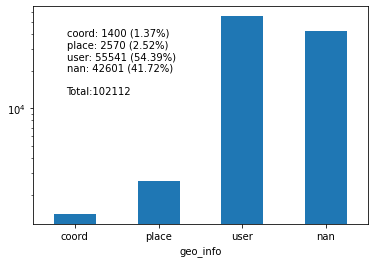

In [13]:
data = gdf_tweets.groupby("geo_info", dropna=False).tweet_id.size()
ax = data.plot.bar()
ax.set_xticklabels(ax.get_xticklabels(), rotation=0);
s = "\n".join([f"{i}: {a} ({a*100/data.sum():.2f}%)" for i,a in data.iteritems()])
s = f"{s}\n\nTotal:{gdf_tweets.shape[0]}"
ax.text(s=s, x=0.1, y=0.9, ha='left', va='top', transform=ax.transAxes);
ax.set_yscale('log')
viz.plt.show()
viz.plt.close()

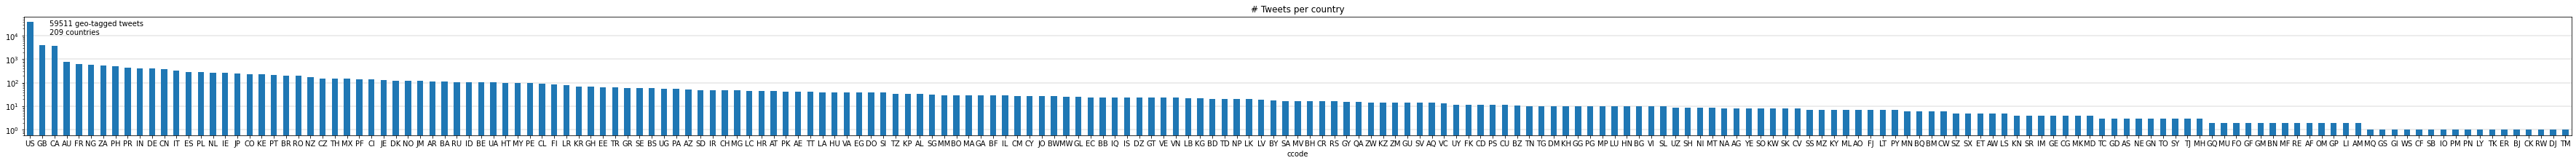

In [14]:
width = gdf_tweets.ccode.nunique()*0.3
tmp = gdf_tweets.query('~geometry.is_empty and geometry not in @geo.NONE and ccode not in @geo.NONE')
ax = tmp.groupby('ccode').tweet_id.size().sort_values(ascending=False).plot.bar(figsize=(width,3), logy=True, rot=0, title='# Tweets per country');
s1 = tmp.shape[0]
s2 = tmp.ccode.nunique()
s = f"{s1} geo-tagged tweets\n{s2} countries"
ax.text(s=s, x=0.01, y=0.97, ha='left', va='top', transform=ax.transAxes);
for y in range(0,5,1):
    ax.axhline(y=10**y, ls='-', lw=0.3, c='grey', zorder=0)
viz.plt.show()
viz.plt.close()

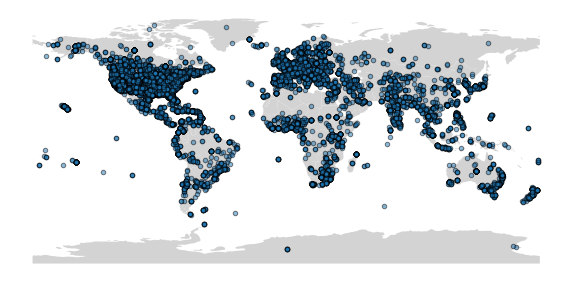

In [21]:
fn = '../plots/ic2s2/tweets_maps.png'
viz.plot_in_map(gdf_tweets, fn)
viz.plt.show()
viz.plt.close()

## Users

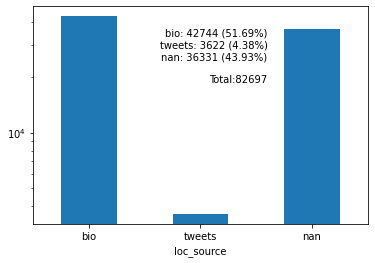

In [16]:
data = gdf_users.groupby("loc_source", dropna=False).user_id.size()
ax = data.plot.bar()
ax.set_xticklabels(ax.get_xticklabels(), rotation=0);
s = "\n".join([f"{i}: {a} ({a*100/data.sum():.2f}%)" for i,a in data.iteritems()])
s = f"{s}\n\nTotal:{gdf_users.shape[0]}"
ax.text(s=s, x=0.7, y=0.9, ha='right', va='top', transform=ax.transAxes);
ax.set_yscale('log')
viz.plt.show()
viz.plt.close()

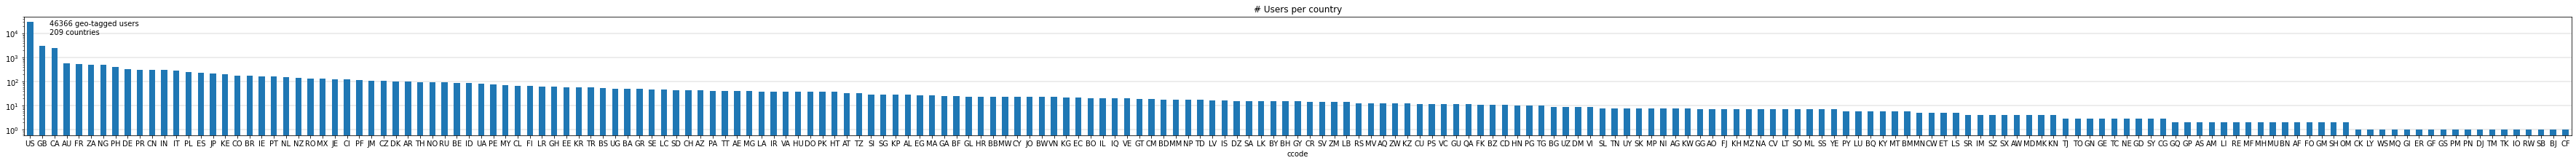

In [22]:
width = gdf_users.ccode.nunique()*0.3
tmp = gdf_users.query('~geometry.is_empty and geometry not in @geo.NONE and ccode not in @geo.NONE')
ax = tmp.groupby('ccode').user_id.size().sort_values(ascending=False).plot.bar(figsize=(width,3), logy=True, rot=0, title='# Users per country');
s = f"{tmp.shape[0]} geo-tagged users\n{tmp.ccode.nunique()} countries"
ax.text(s=s, x=0.01, y=0.97, ha='left', va='top', transform=ax.transAxes);
for y in range(0,5,1):
    ax.axhline(y=10**y, ls='-', lw=0.3, c='grey', zorder=0)
viz.plt.show()
viz.plt.close()

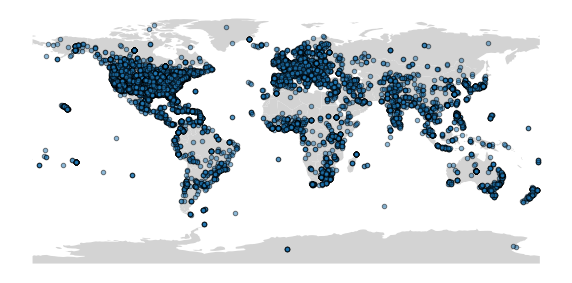

In [18]:
viz.plot_in_map(gdf_users, None)
viz.plt.show()
viz.plt.close()

# No geo-location

## Tweets

In [23]:
gdf_tweets.query("geometry.is_empty or geometry in @geo.NONE").sample(20).drop(columns=['lon','lat','centroid','ccode','score_q6','score_q7','score_q8', 'geo_info', 'scope', 'cashtags'])


,tweet_id,corpus,score_q1,score_q2,score_q3,score_q4,score_q5,total,text,author_id,...,hour,time,date_hour,status,geometry,country,postcode,state,neighborhood,year
37952,269518870199545856,nah rt @kickrockzshawty so when yall pregnant....,0.575863,0.662449,0.541989,0.559634,0.507667,3.832047,Nah RT @KickRockzShawty So when yall pregnant....,143493139,...,19,19:14:40,2012-11-16 19,None,POINT EMPTY,NaN,NaN,NaN,NaN,2012
70042,515885347121950720,girl you is my baby girl you is my baby gotta ...,0.468122,0.592249,0.441215,0.491605,0.478269,3.482101,Girl you is my baby girl you is my baby gotta ...,621256019,...,15,15:27:06,2014-09-27 15,None,POINT EMPTY,NaN,NaN,NaN,NaN,2014
28524,513504592462479362,why smoke weed when you're pregnant???,0.753918,0.823232,0.736024,0.726832,0.600541,4.900424,Why smoke weed when you're pregnant???,924569300,...,1,01:46:49,2014-09-21 1,None,POINT EMPTY,NaN,NaN,NaN,NaN,2014
78455,348098631376728065,"baby copping us weed ,",0.556493,0.647759,0.49068,0.484596,0.576251,4.194754,"Baby copping us weed ,",261371129,...,15,15:22:35,2013-06-21 15,None,POINT EMPTY,NaN,NaN,NaN,NaN,2013
94255,1439031160517140482,a baby will never get accused of smelling like...,0.499576,0.56656,0.484607,0.460187,0.570221,3.597898,a baby will never get accused of smelling like...,912129580688867328,...,0,00:58:59,2021-09-18 0,None,POINT EMPTY,NaN,NaN,NaN,NaN,2021
91787,562522660199215104,womb: weed on my boobs,0.593241,0.552773,0.52919,0.498231,0.503118,3.794150,Womb: Weed On My Boobs,262932368,...,8,08:07:08,2015-02-03 8,None,POINT EMPTY,NaN,NaN,NaN,NaN,2015
41959,179085830449672192,why do some pregnant girls think it is ok to s...,0.657638,0.754957,0.677009,0.668351,0.568022,4.576320,Why do some pregnant girls think it is ok to s...,140175896,...,6,06:06:03,2012-03-12 6,None,POINT EMPTY,NaN,NaN,NaN,NaN,2012
72063,460803692560523266,"baby imma bout to go up in smoke, cause ya sex...",0.45854,0.557552,0.468833,0.432074,0.435938,3.629289,"baby imma bout to go up in smoke, cause ya sex...",601969417,...,15,15:32:16,2014-04-28 15,None,POINT EMPTY,NaN,NaN,NaN,NaN,2014
36163,308246785615355904,i dont even think its necessary to smoke weed ...,0.748024,0.84767,0.738326,0.741582,0.587276,4.901419,I dont even think its necessary to smoke weed ...,913596870,...,16,16:05:35,2013-03-03 16,None,POINT EMPTY,NaN,NaN,NaN,NaN,2013
70796,493495766225522688,my baby always hook the weed up... ^_^ he don'...,0.482933,0.567629,0.428778,0.438082,0.523784,3.384154,My baby always hook the weed up... ^_^ He don'...,26884520,...,20,20:38:54,2014-07-27 20,None,POINT EMPTY,NaN,NaN,NaN,NaN,2014


## Users

In [ ]:
gdf_users.query("geometry.is_empty or geometry in @geo.NONE").sample(20)